# Automated Tech-Support Ticketing System

An end-to-end automated customer support ticketing management system powered by Deep Learning and Large Language Models (LLMs). This project aims to automate incoming ticket classification and generate initial response drafts to enhance customer service efficiency.

## Load Library

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Load Datasets

In [75]:
df = pd.read_csv('https://raw.githubusercontent.com/Genome06/automated-tech-support-ticketing/refs/heads/main/data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv', index_col=False)
df.sample(5)

,flags,instruction,category,intent,response
1991,BMQ,wanna change some items of order {{Order Number}},ORDER,change_order,I can certainly assist you in updating the ite...
5094,BLQ,want help checking the allowed payment methods,PAYMENT,check_payment_methods,Sure! I'm here to assist you in exploring our ...
8545,BL,I don't know how I can speak with customer ser...,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...
59,BEL,I do not know how I can cancel purchase {{Orde...,ORDER,cancel_order,"I pick up what you're putting down, your confu..."
809,BIL,can you help me canceling purchase {{Order Num...,ORDER,cancel_order,I get it that you need assistance with canceli...


## EDA (Explaratory Data Analysis)

### Check Null Values

In [76]:
# Check Null Values using .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [77]:
# # Check Null Values using .isnull()
df.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


### Check Duplicated Values

In [78]:
# Check duplicated values
df.duplicated().any()

np.False_

In [79]:
# Check duplicated values
df.duplicated().sum()

np.int64(0)

### Descriptive Statistics

In [80]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,shiping to {{Delivery City}},ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


### Analysis The Lenght of instruction/ticket teks

In [81]:
# Count Amount of Data Per Category In Category Feature
df['category'].value_counts()

,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


In [82]:
# Count Amount of Data Per intent In Intent Feature
df['intent'].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


The dataset contains 26,872 samples distributed across 11 broad categories and 27 specific intents. Upon initial inspection, we decided to pivot our target labels from 'Category' to 'Intent'. Focusing on Intent classification provides a more granular understanding of customer needs—for instance, distinguishing 'cancel_order' from 'change_order' within the 'ORDER' category—which is essential for building a precise automated support system.

Descriptive Statistics for Text Lengths:
         word_count    char_count
count  26872.000000  26872.000000
mean       8.690979     46.889513
std        2.605004     10.897578
min        1.000000      6.000000
25%        7.000000     40.000000
50%        9.000000     48.000000
75%       11.000000     55.000000
90%       12.000000     59.000000
95%       13.000000     61.000000
99%       14.000000     71.000000
max       16.000000     92.000000

Total words: 233544
Unique words (Vocabulary size): 3191

Top 10 most common words:
[('i', 18874), ('to', 16400), ('the', 6413), ('help', 6253), ('a', 6086), ('do', 5344), ('can', 5274), ('my', 4774), ('how', 4207), ('need', 4059)]


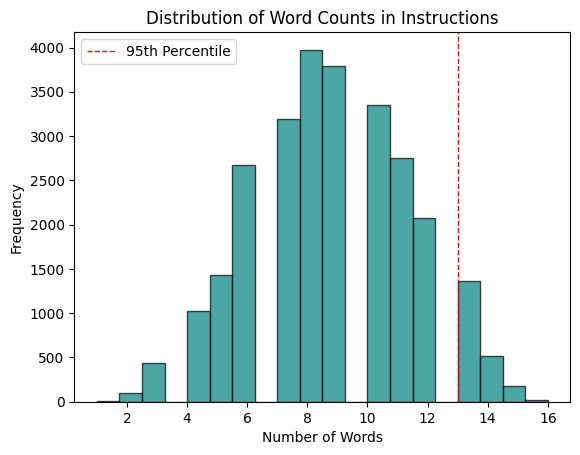

In [83]:
# Analysis The Lenght of instruction/ticket teks

# Word count analysis
df['word_count'] = df['instruction'].apply(lambda x: len(str(x).split()))

# Character count analysis
df['char_count'] = df['instruction'].apply(lambda x: len(str(x)))

# Descriptive statistics
stats = df[['word_count', 'char_count']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Descriptive Statistics for Text Lengths:")
print(stats)

# Plotting word count distribution
plt.hist(df['word_count'], bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Counts in Instructions')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].quantile(0.95), color='red', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.legend()

# Vocabulary Analysis (Unique words)
all_words = ' '.join(df['instruction']).lower().split()
unique_words = set(all_words)
print(f"\nTotal words: {len(all_words)}")
print(f"Unique words (Vocabulary size): {len(unique_words)}")

word_freq = Counter(all_words)
print("\nTop 10 most common words:")
print(word_freq.most_common(10))

Descriptive Statistics for Text Lengths:
       word_count_response  char_count_response
count         26872.000000         26872.000000
mean            104.789037           634.104495
std              52.966204           331.593822
min               9.000000            57.000000
25%              72.000000           427.000000
50%              90.000000           540.000000
75%             124.000000           753.000000
90%             173.000000          1059.000000
95%             206.000000          1295.000000
99%             300.000000          1837.000000
max             402.000000          2472.000000

Total words: 2815891
Unique words (Vocabulary size): 11951

Top 10 most common words:
[('to', 147141), ('the', 127056), ('you', 124697), ('your', 88966), ('and', 63970), ('with', 43179), ('or', 41385), ('our', 41366), ('for', 37625), ('a', 37072)]


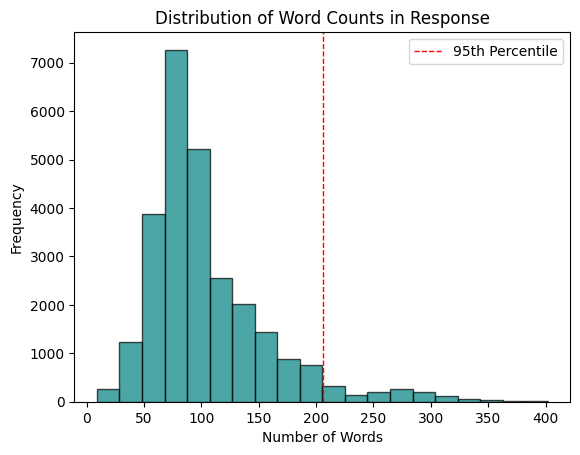

In [84]:
# Analysis The Lenght of Response teks

# Word count analysis
df['word_count_response'] = df['response'].apply(lambda x: len(str(x).split()))

# Character count analysis
df['char_count_response'] = df['response'].apply(lambda x: len(str(x)))

# Descriptive statistics
stats = df[['word_count_response', 'char_count_response']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Descriptive Statistics for Text Lengths:")
print(stats)

# Plotting word count distribution
plt.hist(df['word_count_response'], bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Counts in Response')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count_response'].quantile(0.95), color='red', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.legend()

# Vocabulary Analysis (Unique words)
all_words = ' '.join(df['response']).lower().split()
unique_words = set(all_words)
print(f"\nTotal words: {len(all_words)}")
print(f"Unique words (Vocabulary size): {len(unique_words)}")

word_freq = Counter(all_words)
print("\nTop 10 most common words:")
print(word_freq.most_common(10))

There is a significant disparity between input (Instruction) and output (Response) lengths. Analysis shows that instructions are highly concise, with a mean length of ~9 words and a maximum of 16 words. In contrast, the responses are much more complex, averaging ~105 words with a maximum of 402 words. This finding is critical for our model configuration: a small max_length (e.g., 64 tokens) will be sufficient for the classification task, while the future generation phase will require a much larger token limit.

### Special Character and Placeholder Analysis

In [85]:
# Function to extract text inside {{ }}
def extract_placeholders(text):
    return re.findall(r"\{\{(.*?)\}\}", str(text))

# Apply to all instruction columns
all_placeholders = df['instruction'].apply(extract_placeholders)

# Combine into one big list
flattened_placeholders = [item for sublist in all_placeholders for item in sublist]

# Count the frequency
placeholder_counts = Counter(flattened_placeholders)
placeholder_counts

Counter({'Order Number': 2907,
         'Invoice Number': 8,
         'Person Name': 887,
         'Account Type': 1011,
         'Account Category': 822,
         'Delivery City': 234,
         'Delivery Country': 177,
         'Currency Symbol': 372,
         'Refund Amount': 624})

We identified 9 unique types of placeholders, such as `{{Order Number}}`, `{{Refund Amount}}`, and `{{Account Type}}`. These placeholders serve as anonymized entity markers. Order Number is the most prevalent, appearing in nearly 11% of the instructions. Since these placeholders provide structural context for the model to understand where specific data points are located, we decided to retain them in the training data rather than removing them during preprocessing.

### N-gram Analysis (Unigram, Bigram, Trigram)

In [86]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# Find top bigrams for ALL unique intents
unique_intents = df['intent'].unique()
all_top_bigrams = {}

for itn in unique_intents:
    corpus = df[df['intent'] == itn]['instruction']
    # The get_top_ngram function that we discussed earlier
    all_top_bigrams[itn] = get_top_ngram(corpus, n=2)[:5] # Just take the top 5 to make it neat

# Show some of the most interesting ones
for itn, bigrams in list(all_top_bigrams.items())[:5]:
    print(f"Intent: {itn} -> {bigrams}")

Intent: cancel_order -> [('order number', np.int64(973)), ('purchase order', np.int64(544)), ('order order', np.int64(395)), ('cancel purchase', np.int64(233)), ('cancel order', np.int64(148))]
Intent: change_order -> [('order number', np.int64(965)), ('order order', np.int64(541)), ('purchase order', np.int64(390)), ('item order', np.int64(62)), ('need help', np.int64(62))]
Intent: change_shipping_address -> [('shipping address', np.int64(281)), ('delivery address', np.int64(267)), ('trying update', np.int64(47)), ('trying change', np.int64(41)), ('need assistance', np.int64(40))]
Intent: check_cancellation_fee -> [('early exit', np.int64(189)), ('early termination', np.int64(166)), ('check early', np.int64(103)), ('termination fees', np.int64(61)), ('check termination', np.int64(60))]
Intent: check_invoice -> [('quick look', np.int64(195)), ('look invoice', np.int64(125)), ('bills person', np.int64(109)), ('invoices person', np.int64(95)), ('invoice person', np.int64(75))]


Bigram analysis reveals distinct 'linguistic fingerprints' for each intent. For example, while different intents might share common words, their sequences are unique: 'cancel_order' is characterized by 'purchase order' and 'cancel purchase', while 'check_invoice' is dominated by 'quick look' and 'bills person'. This confirms that using a Transformer-based model (like DistilBERT) is appropriate, as it can effectively capture these sequence-dependent features.

### Word Cloud per Intent

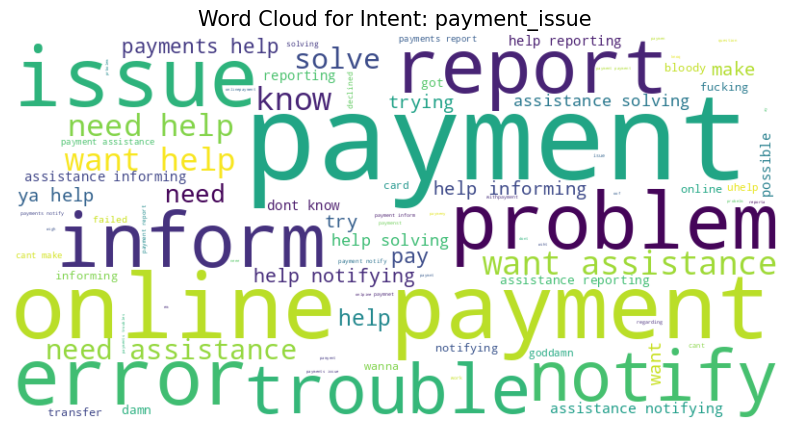

In [87]:
def show_wordcloud(intent_name):
    # Combines all the text in a specific intent
    text = " ".join(df[df['intent'] == intent_name]['instruction'])

    # Create a WordCloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate(text)

    # Display the plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Intent: {intent_name}', fontsize=15)
    plt.axis('off')
    plt.show()

# Usage examples:
show_wordcloud('payment_issue')

To further validate the semantic integrity of our dataset, we generated Word Clouds for various intents. For instance, the payment_issue intent visualization clearly highlights keywords such as 'payment', 'online', 'report', 'trouble', and 'transfer'. This immediate visual feedback confirms that the instructions are highly relevant to their assigned labels and that there is minimal noise in the textual data. These high-density keywords will serve as strong features for our Transformer model during the classification training phase.

### Vocabulary Check

In [88]:
# Combines all instruction text into one large string
all_instructions = " ".join(df['instruction'].astype(str)).lower()

# Split a string into a list of words
words = all_instructions.split()

# Count total words and unique words
total_words = len(words)
unique_words = set(words)
vocab_size = len(unique_words)

print(f"Amount Of Word Inside Datasets: {total_words}")
print(f"Amount of Unique Word (Vocab Size): {vocab_size}")
print(f"Unique Rasio: {(vocab_size / total_words) * 100:.2f}%")

Amount Of Word Inside Datasets: 233544
Amount of Unique Word (Vocab Size): 3191
Unique Rasio: 1.37%


The dataset features a compact vocabulary of 3,191 unique words with a low uniqueness ratio (1.37%). This high frequency of repeated tokens indicates a very consistent and structured dataset, which is ideal for deep learning convergence. Visualizing these tokens through Word Clouds confirms strong semantic alignment; for example, the payment_issue intent is clearly associated with terms like 'report', 'trouble', and 'transfer', ensuring our labels are high-quality and reliable.

## Label Encoding the target (Intent) & Split Data sets

In [89]:
# Label Encoding (Target y)
le = LabelEncoder()
df['intent_label'] = le.fit_transform(df['intent'])

# Save mapping for future (Week 3 & 4)
mapping = dict(zip(range(len(le.classes_)), le.classes_))
with open('intent_mapping.json', 'w') as f:
    json.dump(mapping, f)

print(f"Total Unique Intents: {len(le.classes_)}")

# Train-Validation Split (80% Train, 20% Val)
# We only need the 'instruction' column as X and 'intent_label' as y
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['intent_label'] # Ensure balanced class distribution across both sets
)

print(f"Train size: {len(df_train)}, Val size: {len(df_val)}")

Total Unique Intents: 27
Train size: 21497, Val size: 5375


## Building PyTorch Dataset & DataLoader

In [90]:
class SupportTicketDataset(Dataset):
    """
    A dataset class for processing customer support tickets into a
    format compatible with Transformer models in PyTorch.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        # Returns the total number of data in the dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Retrieve a single row of data based on index
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Perform text tokenization (NLU Processing)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,    # Added [CLS] and [SEP] tokens
            max_length=self.max_len,    # Determined from EDA results
            padding='max_length',       # Padding to ensure uniform tensor length
            truncation=True,            # Truncates text if it exceeds max_len
            return_attention_mask=True, # Generate a mask for padding tokens
            return_tensors='pt',        # Output in PyTorch Tensors format
        )

        # Returns a dictionary containing the processed data.
        return {
            'text': text,               # Useful for debugging during evaluation
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# --- Initialize Objects ---
ticket_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
print(f"Type After Fixed: {type(ticket_tokenizer)}")

# DEBUG: Make sure this is an OBJECT, not a CLASS
if isinstance(ticket_tokenizer, type):
    print("ERROR: The variable is still a CLASS. Make sure .from_pretrained() is called.")
else:
    print(f"SUCCESS: Variable is of type OBJECT {type(ticket_tokenizer)}")
    # Function Tes
    test = ticket_tokenizer("test")
    print("Tokenization Test Successful!")

# Create a Dataset instance (Use max_len=64 from our EDA results)
MAX_LEN = 64
train_dataset = SupportTicketDataset(
    df_train['instruction'],
    df_train['intent_label'],
    ticket_tokenizer,
    MAX_LEN
)

# Create a DataLoader (The Batch Factory)
val_dataset = SupportTicketDataset(
    df_val['instruction'],
    df_val['intent_label'],
    ticket_tokenizer,
    MAX_LEN
)

# Re-create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Final Verification
sample_batch = next(iter(train_loader))
print("\nBatch Verification SUCCESS!")
print(f"Input IDs shape: {sample_batch['input_ids'].shape}")

Type After Fixed: <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
SUCCESS: Variable is of type OBJECT <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
Tokenization Test Successful!

Batch Verification SUCCESS!
Input IDs shape: torch.Size([32, 64])
